In [ ]:
# Install all required packages
!pip install pandas numpy scikit-learn vaderSentiment
!pip install sentence-transformers
!pip install bertopic
!pip install umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.4 MB/s eta 0:00:00


Total posts: 1709
Total labeled images: 1219
Total comments: 15647
Posts with sentiment: 1709
Total images with sentiment: 1219
Images after cleaning: 1219

IMAGE COUNT BY PERSON CATEGORY

person
solo         941
group        154
selfie        98
no_person     26
Name: count, dtype: int64

Average Sentiment by PERSON Category

person
no_person    0.583236
group        0.541541
solo         0.541052
selfie       0.454125
Name: sentiment, dtype: float64


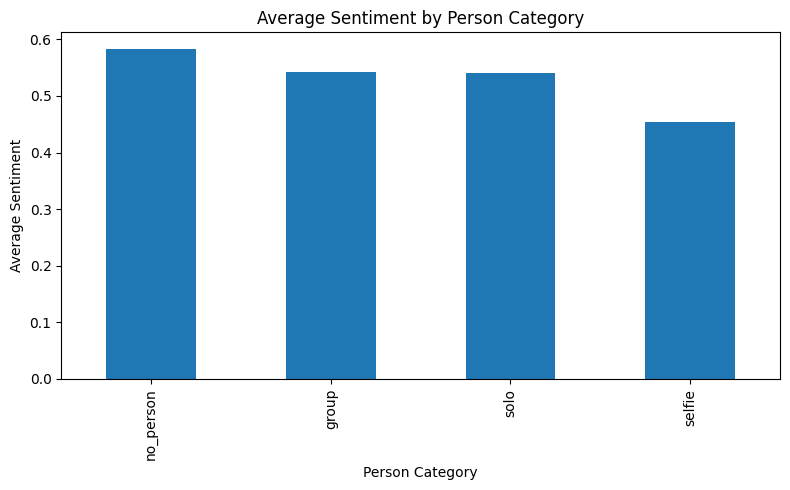


IMAGE COUNT BY CONTEXT CATEGORY

context
outdoors            512
everyday            409
animal               89
sport_gym            85
food_restaurant      44
music_performing     34
nightlife            30
travel_landmark      16
Name: count, dtype: int64

Average Sentiment by CONTEXT Category

context
food_restaurant     0.577924
music_performing    0.565747
animal              0.554543
outdoors            0.544780
travel_landmark     0.534027
everyday            0.521909
nightlife           0.517724
sport_gym           0.490742
Name: sentiment, dtype: float64


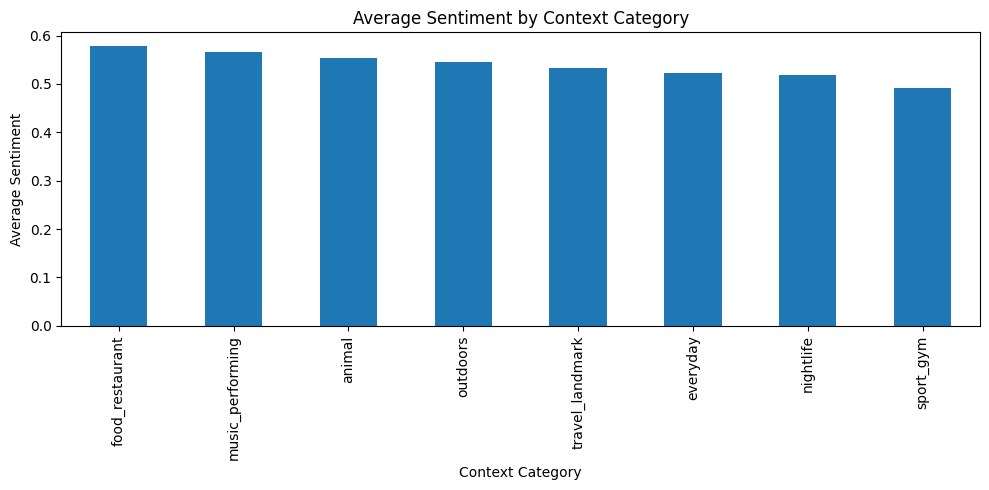


IMAGE COUNT BY PERSON × CONTEXT

       person           context  image_count
20       solo          outdoors          419
16       solo          everyday          273
15       solo            animal           73
12     selfie          everyday           72
21       solo         sport_gym           70
4       group          outdoors           63
1       group          everyday           62
17       solo   food_restaurant           39
18       solo  music_performing           34
13     selfie          outdoors           23
19       solo         nightlife           17
22       solo   travel_landmark           16
5       group         sport_gym           13
6   no_person            animal           13
3       group         nightlife           11
10  no_person          outdoors            7
2       group   food_restaurant            3
0       group            animal            2
7   no_person          everyday            2
8   no_person   food_restaurant            2
14     selfie        

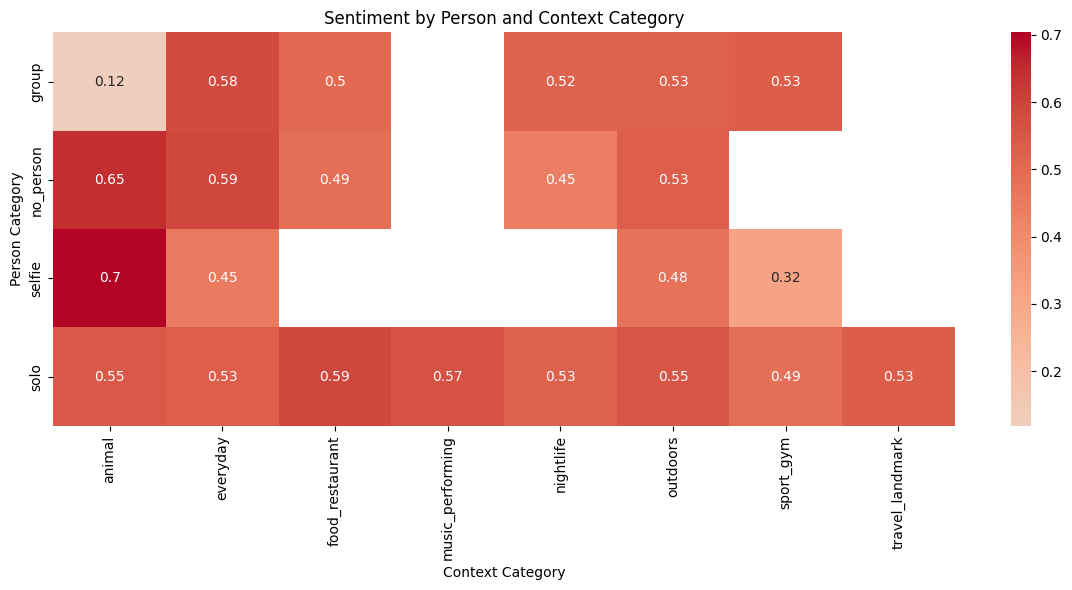


Top 10 Most Positive Image Types

       person           context  avg_sentiment  image_count
11     selfie            animal       0.703660            1
6   no_person            animal       0.646276           13
7   no_person          everyday       0.591495            2
17       solo   food_restaurant       0.588214           39
1       group          everyday       0.576761           62
18       solo  music_performing       0.565747           34
20       solo          outdoors       0.551422          419
15       solo            animal       0.548094           73
5       group         sport_gym       0.534507           13
22       solo   travel_landmark       0.534027           16

Top 10 Most Negative Image Types

       person          context  avg_sentiment  image_count
19       solo        nightlife       0.525848           17
3       group        nightlife       0.518353           11
2       group  food_restaurant       0.504450            3
21       solo        sport_gym    

In [ ]:

import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


#LOAD DATA


# Load JSON (comments)
with open("profile_review_posts(real).json","r") as f:
    raw_data = json.load(f)

posts_df = pd.DataFrame(raw_data)
posts_df = posts_df.rename(columns={"id":"post_id"})

print("Total posts:", len(posts_df))

# Load CSV (CORRECT labels)
labels_df = pd.read_csv("crop_labels_manual.csv")

# Extract post_id from filename
labels_df["post_id"] = labels_df["filename"].apply(lambda x: x.split("_")[0])

print("Total labeled images:", len(labels_df))


#SENTIMENT MODEL


analyzer = SentimentIntensityAnalyzer()


# COMPUTE SENTIMENT PER COMMENT

all_comments = []

for _, row in posts_df.iterrows():

    comments = row["comments"]

    if isinstance(comments, list):

        for c in comments:

            text = c.get("body", "")

            if text == "[deleted]":
                continue

            score = analyzer.polarity_scores(text)["compound"]

            all_comments.append({
                "post_id": row["post_id"],
                "comment": text,
                "sentiment": score
            })

comments_df = pd.DataFrame(all_comments)

print("Total comments:", len(comments_df))


#COMPUTE POST-LEVEL SENTIMENT

post_sentiment = (
    comments_df
    .groupby("post_id")["sentiment"]
    .mean()
    .reset_index()
)

print("Posts with sentiment:", len(post_sentiment))


#CREATE IMAGE-LEVEL DATASET (USING CSV LABELS)

# Merge sentiment onto each image
image_df = labels_df.merge(post_sentiment, on="post_id", how="inner")

# Rename for clarity
image_df = image_df.rename(columns={
    "filename": "image",
    "person": "person",
    "context": "context"
})

print("Total images with sentiment:", len(image_df))


#CLEAN DATA

image_df = image_df.dropna(subset=["person","context","sentiment"])

print("Images after cleaning:", len(image_df))


#MARGINAL SENTIMENT BY PERSON CATEGORY

print("\nIMAGE COUNT BY PERSON CATEGORY\n")
print(image_df["person"].value_counts())

person_sentiment = (
    image_df
    .groupby("person")["sentiment"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Sentiment by PERSON Category\n")
print(person_sentiment)


# VISUALIZATION: PERSON SENTIMENT

plt.figure(figsize=(8,5))
person_sentiment.plot(kind="bar")

plt.title("Average Sentiment by Person Category")
plt.ylabel("Average Sentiment")
plt.xlabel("Person Category")

plt.tight_layout()
plt.show()


#MARGINAL SENTIMENT BY CONTEXT CATEGORY

print("\nIMAGE COUNT BY CONTEXT CATEGORY\n")
print(image_df["context"].value_counts())

context_sentiment = (
    image_df
    .groupby("context")["sentiment"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Sentiment by CONTEXT Category\n")
print(context_sentiment)


#VISUALIZATION: CONTEXT SENTIMENT

plt.figure(figsize=(10,5))
context_sentiment.plot(kind="bar")

plt.title("Average Sentiment by Context Category")
plt.ylabel("Average Sentiment")
plt.xlabel("Context Category")

plt.tight_layout()
plt.show()


#PERSON × CONTEXT COMBINATIONS

print("\nIMAGE COUNT BY PERSON × CONTEXT\n")

combo_counts = (
    image_df
    .groupby(["person","context"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

print(combo_counts)

combo_sentiment = (
    image_df
    .groupby(["person","context"])
    .agg(
        avg_sentiment=("sentiment","mean"),
        image_count=("sentiment","size")
    )
    .reset_index()
    .sort_values("avg_sentiment", ascending=False)
)

print("\nSentiment by Person × Context\n")
print(combo_sentiment)


#SAVE RESULTS

person_sentiment.to_csv("person_sentiment.csv")
context_sentiment.to_csv("context_sentiment.csv")
combo_sentiment.to_csv("person_context_sentiment.csv")

print("\nResults saved")


#HEATMAP MATRIX

heatmap_data = image_df.pivot_table(
    values="sentiment",
    index="person",
    columns="context",
    aggfunc="mean"
)

print("\nSentiment Matrix\n")
print(heatmap_data)


#HEATMAP VISUALIZATION

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Sentiment by Person and Context Category")

plt.xlabel("Context Category")
plt.ylabel("Person Category")

plt.tight_layout()
plt.show()

#TOP & BOTTOM IMAGE TYPES


print("\nTop 10 Most Positive Image Types\n")
print(combo_sentiment.head(10))

print("\nTop 10 Most Negative Image Types\n")
print(combo_sentiment.tail(10))


print("\nPipeline Complete")

In [ ]:
post_sentiment.to_csv("post_sentiment.csv", index=False)
meta.to_csv("meta.csv", index=False)